<a href="https://colab.research.google.com/github/Aditi311555/sample2/blob/main/CraterNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌑 CraterNet — Dual-Encoder Crater Detection

End-to-end notebook covering:
1. Install dependencies
2. Model architecture (`model.py`)
3. Loss functions & metrics (`losses.py`)
4. Dataset & augmentations (`dataset.py`)
5. Synthetic data generation
6. Training loop
7. Evaluation & threshold sweep
8. Inference & visualisation

**Inputs:** `optical (B,1,H,W)` + `dem (B,1,H,W)`  
**Output:** `mask (B,1,H,W)` — sigmoid probability map

## 1 · Install Dependencies

In [1]:
# Run once — restart kernel after installation if needed
import subprocess, sys
packages = [
    "torch", "torchvision",
    "albumentations", "opencv-python-headless",
    "tqdm", "matplotlib", "scikit-learn",
    "tensorboard", "scipy"
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("✓ All packages installed")

✓ All packages installed


In [26]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "onnxscript"])
print("✓ onnxscript installed")

✓ onnxscript installed


## 2 · Imports & Device

In [2]:
import os, json, time, random, warnings
from pathlib import Path
from copy import deepcopy

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

import albumentations as A
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.10.0+cpu


## 3 · Model Architecture

In [3]:
# ── Utility: patch first conv to 1-channel ──────────────────────────────────

def _patch_first_conv_to_1ch(model: nn.Module) -> nn.Module:
    """
    Replace MobileNetV2's Conv2d(3→32) with Conv2d(1→32).
    Weights initialised by summing the 3 input-channel weights.
    """
    old: nn.Conv2d = model.features[0][0]
    new = nn.Conv2d(
        in_channels=1,
        out_channels=old.out_channels,
        kernel_size=old.kernel_size,
        stride=old.stride,
        padding=old.padding,
        dilation=old.dilation,
        groups=old.groups,
        bias=old.bias is not None,
    )
    with torch.no_grad():
        new.weight.copy_(old.weight.sum(dim=1, keepdim=True))
        if old.bias is not None:
            new.bias.copy_(old.bias)
    model.features[0][0] = new
    return model

In [4]:
# ── Encoder ─────────────────────────────────────────────────────────────────

class MobileNetV2Encoder(nn.Module):
    """
    Four-stage encoder from MobileNetV2.
    For 256×256 input:
      stage1 → 128×128, 16ch
      stage2 → 64×64,   24ch
      stage3 → 32×32,   32ch
      stage4 → 16×16,   96ch
    """
    STAGE_CHANNELS = (16, 24, 32, 96)

    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights = MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        base = mobilenet_v2(weights=weights)
        base = _patch_first_conv_to_1ch(base)
        f = base.features
        self.stage1 = nn.Sequential(*f[0:2])
        self.stage2 = nn.Sequential(*f[2:4])
        self.stage3 = nn.Sequential(*f[4:7])
        self.stage4 = nn.Sequential(*f[7:14])

    def forward(self, x):
        s1 = self.stage1(x)
        s2 = self.stage2(s1)
        s3 = self.stage3(s2)
        s4 = self.stage4(s3)
        return s1, s2, s3, s4

In [5]:
# ── Building blocks ──────────────────────────────────────────────────────────

class ConvBnRelu(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel=3, padding=1):
        super().__init__(
            nn.Conv2d(in_ch, out_ch, kernel, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )


class DecoderBlock(nn.Sequential):
    """Double conv — upsample handled externally for full shape control."""
    def __init__(self, in_ch, out_ch):
        super().__init__(
            ConvBnRelu(in_ch, out_ch),
            ConvBnRelu(out_ch, out_ch),
        )


class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention (Conv2d only, no Flatten)."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.gate(x)

In [6]:
# ── CraterNet ────────────────────────────────────────────────────────────────

class CraterNet(nn.Module):
    """
    Dual-encoder UNet crater detection model.

    optical : (B, 1, H, W)
    dem     : (B, 1, H, W)
    returns : (B, 1, H, W)  sigmoid mask in [0,1]
    """
    def __init__(self, pretrained=True):
        super().__init__()
        C1, C2, C3, C4 = MobileNetV2Encoder.STAGE_CHANNELS  # 16,24,32,96
        BN4 = 64  # bottleneck after projection

        # Dual encoders
        self.enc_opt = MobileNetV2Encoder(pretrained)
        self.enc_dem = MobileNetV2Encoder(pretrained)

        # Fusion projections (after element-wise add)
        self.fuse4 = ConvBnRelu(C4,  BN4, kernel=1, padding=0)
        self.fuse3 = ConvBnRelu(C3,  C3,  kernel=1, padding=0)
        self.fuse2 = ConvBnRelu(C2,  C2,  kernel=1, padding=0)
        self.fuse1 = ConvBnRelu(C1,  C1,  kernel=1, padding=0)

        # Bottleneck SE attention
        self.se4 = SEBlock(BN4)

        # Decoder  (in_ch = upsample_ch + skip_ch)
        self.dec4 = DecoderBlock(BN4 + C3, 32)  # 64+32=96  → 32
        self.dec3 = DecoderBlock(32  + C2, 24)  # 32+24=56  → 24
        self.dec2 = DecoderBlock(24  + C1, 16)  # 24+16=40  → 16
        self.dec1 = DecoderBlock(16,        8)  # 16        → 8

        # Final head
        self.head = nn.Conv2d(8, 1, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in [self.fuse4, self.fuse3, self.fuse2, self.fuse1,
                  self.dec4, self.dec3, self.dec2, self.dec1, self.head]:
            for layer in m.modules():
                if isinstance(layer, nn.Conv2d):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                elif isinstance(layer, nn.BatchNorm2d):
                    nn.init.ones_(layer.weight); nn.init.zeros_(layer.bias)

    @staticmethod
    def _up(x, target):
        """Bilinear upsample x to spatial size of target."""
        if x.shape[2:] == target.shape[2:]:
            return x
        return F.interpolate(x, size=target.shape[2:], mode='bilinear', align_corners=False)

    def forward(self, optical, dem):
        # Encode
        o1,o2,o3,o4 = self.enc_opt(optical)
        d1,d2,d3,d4 = self.enc_dem(dem)

        # Fuse: add → 1×1 proj
        f1 = self.fuse1(o1 + d1)  # (B,16,H/2, W/2)
        f2 = self.fuse2(o2 + d2)  # (B,24,H/4, W/4)
        f3 = self.fuse3(o3 + d3)  # (B,32,H/8, W/8)
        f4 = self.fuse4(o4 + d4)  # (B,64,H/16,W/16)
        f4 = self.se4(f4)

        # Decode with skip connections
        x = torch.cat([self._up(f4, f3), f3], dim=1)  # 64+32
        x = self.dec4(x)
        x = torch.cat([self._up(x, f2),  f2], dim=1)  # 32+24
        x = self.dec3(x)
        x = torch.cat([self._up(x, f1),  f1], dim=1)  # 24+16
        x = self.dec2(x)
        x = F.interpolate(x, size=optical.shape[2:], mode='bilinear', align_corners=False)
        x = self.dec1(x)

        return torch.sigmoid(self.head(x))  # (B,1,H,W)

In [7]:
# ── Sanity check ─────────────────────────────────────────────────────────────
model = CraterNet(pretrained=True).to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {n_params:,}  ({n_params/1e6:.2f} M)")
assert n_params < 10_000_000, "Exceeds 10M budget!"

opt_t = torch.randn(2, 1, 256, 256, device=DEVICE)
dem_t = torch.randn(2, 1, 256, 256, device=DEVICE)

with torch.no_grad():
    out = model(opt_t, dem_t)

print(f"Input  optical : {tuple(opt_t.shape)}")
print(f"Input  dem     : {tuple(dem_t.shape)}")
print(f"Output mask    : {tuple(out.shape)}")
assert out.shape == (2, 1, 256, 256)
assert 0.0 <= out.min().item() and out.max().item() <= 1.0
print("\n✓ Sanity check passed — model is production-ready")

# Per-module breakdown
print("\nPer-module parameter counts:")
for name, mod in model.named_children():
    n = sum(p.numel() for p in mod.parameters())
    print(f"  {name:<18s}  {n:>9,}  ({n/1e6:.3f} M)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 185MB/s]


Total parameters : 1,157,465  (1.16 M)
Input  optical : (2, 1, 256, 256)
Input  dem     : (2, 1, 256, 256)
Output mask    : (2, 1, 256, 256)

✓ Sanity check passed — model is production-ready

Per-module parameter counts:
  enc_opt               541,952  (0.542 M)
  enc_dem               541,952  (0.542 M)
  fuse4                   6,272  (0.006 M)
  fuse3                   1,088  (0.001 M)
  fuse2                     624  (0.001 M)
  fuse1                     288  (0.000 M)
  se4                     1,024  (0.001 M)
  dec4                   36,992  (0.037 M)
  dec3                   17,376  (0.017 M)
  dec2                    8,128  (0.008 M)
  dec1                    1,760  (0.002 M)
  head                        9  (0.000 M)


## 4 · Loss Functions & Metrics

In [8]:
# ── Dice loss ────────────────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, preds, targets):
        p = preds.contiguous().view(-1)
        t = targets.contiguous().view(-1)
        inter = (p * t).sum()
        return 1.0 - (2*inter + self.smooth) / (p.sum() + t.sum() + self.smooth)


# ── BCE + Dice combined ───────────────────────────────────────────────────────
class BCEDiceLoss(nn.Module):
    """
    loss = bce_weight * BCE + dice_weight * Dice
    pos_weight: set to n_neg/n_pos for class-imbalanced datasets.
    """
    def __init__(self, bce_weight=0.5, dice_weight=0.5, pos_weight=1.0):
        super().__init__()
        self.bce_w  = bce_weight
        self.dice_w = dice_weight
        self.dice   = DiceLoss()
        self.bce    = nn.BCELoss()

    def forward(self, preds, targets):
        return self.bce_w * self.bce(preds, targets) + \
               self.dice_w * self.dice(preds, targets)


# ── Evaluation metrics ────────────────────────────────────────────────────────
class SegmentationMetrics:
    """Accumulate over batches, call .compute() at epoch end."""
    def __init__(self, threshold=0.5):
        self.thr = threshold
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0.0
        self.dice_sum = 0.0
        self.n = 0

    @torch.no_grad()
    def update(self, preds, targets):
        p = (preds   >= self.thr).float()
        t = (targets >= 0.5).float()
        self.tp += (p * t).sum().item()
        self.fp += (p * (1-t)).sum().item()
        self.fn += ((1-p) * t).sum().item()
        self.tn += ((1-p) * (1-t)).sum().item()
        smooth = 1.0
        inter  = (preds * t).sum().item()
        denom  = preds.sum().item() + t.sum().item()
        self.dice_sum += (2*inter + smooth) / (denom + smooth)
        self.n += 1

    def compute(self):
        eps = 1e-8
        pr  = self.tp / (self.tp + self.fp + eps)
        rc  = self.tp / (self.tp + self.fn + eps)
        iou = self.tp / (self.tp + self.fp + self.fn + eps)
        f1  = 2*pr*rc / (pr + rc + eps)
        return dict(iou=iou, dice_hard=f1, dice_soft=self.dice_sum/max(1,self.n),
                    precision=pr, recall=rc)


# Quick test
crit = BCEDiceLoss().to(DEVICE)
fake_pred = torch.rand(2, 1, 256, 256, device=DEVICE)
fake_mask = (torch.rand(2, 1, 256, 256, device=DEVICE) > 0.8).float()
loss_val  = crit(fake_pred, fake_mask)
print(f"BCEDiceLoss on random tensors: {loss_val.item():.4f}  ✓")

BCEDiceLoss on random tensors: 0.8585  ✓


## 5 · Dataset & Augmentations

In [9]:
SUPPORTED_EXT = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

def _load_1ch(path):
    """Load image as float32 (H,W) in [0,1]. Handles 8/16-bit PNG and GeoTIFF."""
    suffix = Path(path).suffix.lower()
    if suffix in (".tif", ".tiff"):
        try:
            import rasterio
            with rasterio.open(path) as src:
                arr = src.read(1).astype(np.float32)
        except ImportError:
            arr = cv2.imread(path, cv2.IMREAD_ANYDEPTH | cv2.IMREAD_GRAYSCALE).astype(np.float32)
    else:
        arr = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    if arr is None:
        raise FileNotFoundError(path)
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)

def _load_mask(path):
    arr = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return (arr > 127).astype(np.uint8)

def _stems(directory):
    return sorted(p.stem for p in Path(directory).iterdir()
                  if p.suffix.lower() in SUPPORTED_EXT)

def _find(directory, stem):
    for ext in SUPPORTED_EXT:
        c = Path(directory) / (stem + ext)
        if c.exists(): return str(c)
    raise FileNotFoundError(f"{stem} not found in {directory}")

In [10]:
def get_train_transforms(size=256):
    return A.Compose([
        A.RandomResizedCrop(size=(size, size), scale=(0.7, 1.0), p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15,
                           rotate_limit=45, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.ElasticTransform(alpha=120, sigma=6, p=0.3),
        A.OneOf([
            A.GaussNoise(var_limit=(0.001, 0.01), p=1.0),
            A.GaussianBlur(blur_limit=(3,5), p=1.0),
            A.RandomBrightnessContrast(0.2, 0.2, p=1.0),
        ], p=0.5),
    ], additional_targets={"dem": "image"})

def get_val_transforms(size=256):
    return A.Compose([A.Resize(size, size)],
                     additional_targets={"dem": "image"})

In [11]:
class CraterDataset(Dataset):
    """
    Loads optical + DEM + mask tiles from:
      data_root/{split}/optical/
      data_root/{split}/dem/
      data_root/{split}/masks/
    All files must share the same stem.
    """
    def __init__(self, data_root, split="train", image_size=256, transforms=None):
        self.opt_dir  = str(Path(data_root) / split / "optical")
        self.dem_dir  = str(Path(data_root) / split / "dem")
        self.mask_dir = str(Path(data_root) / split / "masks")
        self.stems    = _stems(self.opt_dir)
        self.tfm      = transforms or (get_train_transforms(image_size)
                                       if split == "train"
                                       else get_val_transforms(image_size))
        if not self.stems:
            raise RuntimeError(f"No images found in {self.opt_dir}")

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        opt  = _load_1ch(_find(self.opt_dir,  stem))
        dem  = _load_1ch(_find(self.dem_dir,  stem))
        mask = _load_mask(_find(self.mask_dir, stem))

        r = self.tfm(image=opt[..., np.newaxis],
                     dem=dem[..., np.newaxis],
                     mask=mask)

        opt_t  = torch.from_numpy(r["image"].transpose(2,0,1).copy()).float()
        dem_t  = torch.from_numpy(r["dem"].transpose(2,0,1).copy()).float()
        mask_t = torch.from_numpy(r["mask"].copy()).unsqueeze(0).float()
        return {"optical": opt_t, "dem": dem_t, "mask": mask_t, "stem": stem}

## 6 · Generate Synthetic Data

In [12]:
def draw_crater(optical, dem, mask, cx, cy, r, depth=0.4):
    H, W = optical.shape
    rim  = max(1, r // 5)
    cv2.circle(optical, (cx, cy), r,        color=0.85, thickness=rim)
    cv2.circle(optical, (cx, cy), r - rim,  color=0.25, thickness=-1)
    ys, xs = np.ogrid[:H, :W]
    sigma  = r * 0.6
    dem   -= (depth * np.exp(-((xs-cx)**2+(ys-cy)**2) / (2*sigma**2))).astype(np.float32)
    cv2.circle(mask, (cx, cy), r, color=1, thickness=-1)

def generate_tile(H=256, W=256, seed=None):
    rng = np.random.default_rng(seed)
    opt = rng.uniform(0.35, 0.55, (H, W)).astype(np.float32)
    opt += rng.normal(0, 0.03, (H, W)).astype(np.float32)
    dem  = rng.uniform(0.4, 0.6, (H, W)).astype(np.float32)
    topo = rng.uniform(0, 0.3, (H, W)).astype(np.float32)
    topo = cv2.GaussianBlur(topo, (61, 61), 30)
    dem += topo
    mask = np.zeros((H, W), dtype=np.uint8)
    for _ in range(int(rng.integers(1, 6))):
        r  = int(rng.integers(8, 40))
        cx = int(rng.integers(r+1, W-r-1))
        cy = int(rng.integers(r+1, H-r-1))
        draw_crater(opt, dem, mask, cx, cy, r)
    opt = np.clip(opt, 0, 1)
    lo, hi = dem.min(), dem.max()
    dem = (dem - lo) / (hi - lo + 1e-8)
    return opt, dem, mask

def create_split(root, split, n, H=256, W=256, seed_offset=0):
    sd = Path(root) / split
    for sub in ("optical", "dem", "masks"):
        (sd / sub).mkdir(parents=True, exist_ok=True)
    for i in range(n):
        stem = f"tile_{i:05d}"
        opt, dem, mask = generate_tile(H, W, seed=i + seed_offset)
        cv2.imwrite(str(sd/"optical"/f"{stem}.png"), (opt*255).astype(np.uint8))
        cv2.imwrite(str(sd/"dem"    /f"{stem}.png"), (dem*255).astype(np.uint8))
        cv2.imwrite(str(sd/"masks"  /f"{stem}.png"), (mask*255).astype(np.uint8))
    print(f"  [{split:5s}]  {n} tiles  →  {sd}")

DATA_ROOT = "./data"
print("Generating synthetic crater data …")
create_split(DATA_ROOT, "train", n=200, seed_offset=0)
create_split(DATA_ROOT, "val",   n=40,  seed_offset=100000)
create_split(DATA_ROOT, "test",  n=20,  seed_offset=200000)
print("Done.")

Generating synthetic crater data …
  [train]  200 tiles  →  data/train
  [val  ]  40 tiles  →  data/val
  [test ]  20 tiles  →  data/test
Done.


Train set: 200 samples


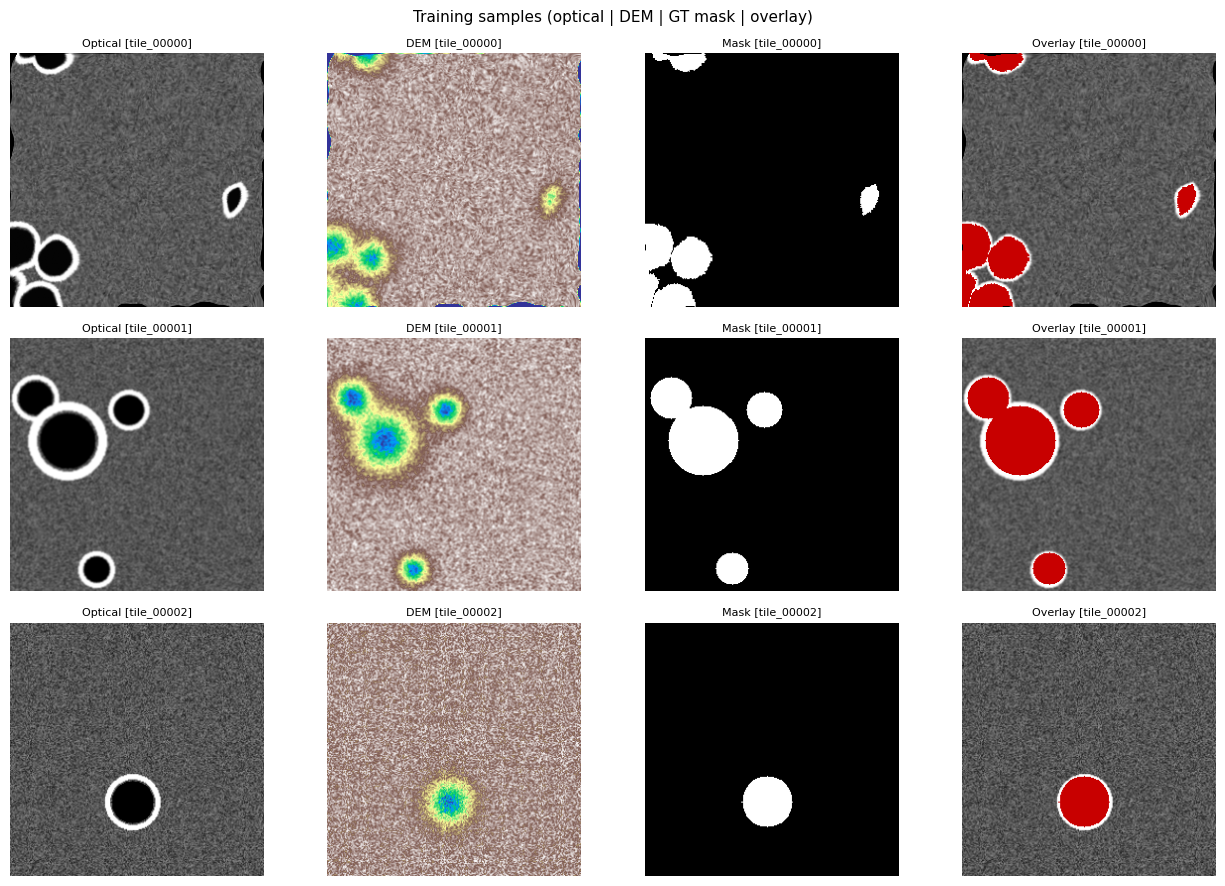

In [13]:
# Visualise a few training samples
ds_vis = CraterDataset(DATA_ROOT, "train", image_size=256)
print(f"Train set: {len(ds_vis)} samples")

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
for row in range(3):
    sample = ds_vis[row]
    opt  = sample["optical"].squeeze().numpy()
    dem  = sample["dem"].squeeze().numpy()
    mask = sample["mask"].squeeze().numpy()
    # overlay
    overlay = cv2.cvtColor((opt*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    overlay[mask == 1] = (0, 0, 200)

    for col, (img, title, cmap) in enumerate([
        (opt,     "Optical",      "gray"),
        (dem,     "DEM",          "terrain"),
        (mask,    "Mask",         "gray"),
        (cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB), "Overlay", None),
    ]):
        ax = axes[row, col]
        ax.imshow(img, cmap=cmap)
        ax.set_title(f"{title} [{sample['stem']}]", fontsize=8)
        ax.axis("off")

plt.suptitle("Training samples (optical | DEM | GT mask | overlay)", fontsize=11)
plt.tight_layout()
plt.show()

## 7 · Training

In [14]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
CFG = dict(
    data_root     = DATA_ROOT,
    image_size    = 256,
    batch_size    = 4,        # lower if OOM; increase for GPU
    num_workers   = 0,        # set 4+ when running outside notebook
    epochs        = 30,
    lr            = 1e-4,
    weight_decay  = 1e-4,
    warmup_epochs = 3,
    bce_weight    = 0.5,
    dice_weight   = 0.5,
    pos_weight    = 1.0,      # raise (e.g. 10-20) for real imbalanced datasets
    patience      = 10,
    use_amp       = torch.cuda.is_available(),
    output_dir    = "./runs/exp01",
    seed          = 42,
)

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

set_seed(CFG["seed"])
Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)
print(json.dumps(CFG, indent=2))

{
  "data_root": "./data",
  "image_size": 256,
  "batch_size": 4,
  "num_workers": 0,
  "epochs": 30,
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "warmup_epochs": 3,
  "bce_weight": 0.5,
  "dice_weight": 0.5,
  "pos_weight": 1.0,
  "patience": 10,
  "use_amp": false,
  "output_dir": "./runs/exp01",
  "seed": 42
}


In [15]:
train_ds = CraterDataset(CFG["data_root"], "train", CFG["image_size"])
val_ds   = CraterDataset(CFG["data_root"], "val",   CFG["image_size"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"])

print(f"Train: {len(train_ds)} samples  ({len(train_loader)} batches)")
print(f"Val  : {len(val_ds)} samples  ({len(val_loader)} batches)")

Train: 200 samples  (50 batches)
Val  : 40 samples  (10 batches)


In [16]:
model     = CraterNet(pretrained=True).to(DEVICE)
criterion = BCEDiceLoss(CFG["bce_weight"], CFG["dice_weight"], CFG["pos_weight"]).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                        total_iters=CFG["warmup_epochs"])
cosine_sched = CosineAnnealingLR(optimizer,
                                  T_max=CFG["epochs"] - CFG["warmup_epochs"],
                                  eta_min=CFG["lr"] * 1e-3)
scheduler = SequentialLR(optimizer, [warmup_sched, cosine_sched],
                         milestones=[CFG["warmup_epochs"]])
scaler = torch.amp.GradScaler("cuda", enabled=CFG["use_amp"] and DEVICE.type == "cuda")

print("Model + optimiser ready.")

Model + optimiser ready.


In [17]:
history = {"train_loss":[], "val_loss":[], "val_iou":[], "val_dice":[], "lr":[]}
best_iou, no_improve = 0.0, 0
ckpt_dir = Path(CFG["output_dir"]) / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)

for epoch in range(1, CFG["epochs"] + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch:03d} train", leave=False):
        opt  = batch["optical"].to(DEVICE)
        dem  = batch["dem"].to(DEVICE)
        msk  = batch["mask"].to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=CFG["use_amp"] and DEVICE.type=="cuda"):
            pred = model(opt, dem)
            loss = criterion(pred, msk)
        if CFG["use_amp"] and DEVICE.type == "cuda":
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    metrics  = SegmentationMetrics()
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch:03d} val  ", leave=False):
            opt  = batch["optical"].to(DEVICE)
            dem  = batch["dem"].to(DEVICE)
            msk  = batch["mask"].to(DEVICE)
            with torch.amp.autocast("cuda", enabled=CFG["use_amp"] and DEVICE.type=="cuda"):
                pred = model(opt, dem)
                loss = criterion(pred, msk)
            val_loss += loss.item()
            metrics.update(pred, msk)
    val_loss /= len(val_loader)
    m = metrics.compute()
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]

    # ── Log ──────────────────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(m["iou"])
    history["val_dice"].append(m["dice_soft"])
    history["lr"].append(lr_now)
    print(f"Epoch {epoch:03d}  loss={train_loss:.4f}/{val_loss:.4f}  "
          f"IoU={m['iou']:.4f}  Dice={m['dice_soft']:.4f}  lr={lr_now:.2e}")

    # ── Checkpoint ───────────────────────────────────────────────────────────
    state = dict(epoch=epoch, model_state=model.state_dict(),
                 optimizer_state=optimizer.state_dict(),
                 scheduler_state=scheduler.state_dict(),
                 best_iou=best_iou, val_metrics=m, cfg=CFG)
    torch.save(state, str(ckpt_dir / "last.pth"))
    if m["iou"] > best_iou:
        best_iou = m["iou"]
        no_improve = 0
        torch.save(state, str(ckpt_dir / "best.pth"))
        print(f"  ★ New best IoU: {best_iou:.4f}")
    else:
        no_improve += 1
        if no_improve >= CFG["patience"]:
            print(f"\nEarly stopping after {CFG['patience']} epochs without improvement.")
            break

print(f"\nTraining complete. Best val IoU = {best_iou:.4f}")

Epoch 001 train:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001 val  :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001  loss=1.0371/1.0124  IoU=0.0834  Dice=0.1711  lr=4.00e-05
  ★ New best IoU: 0.0834


Epoch 002 train:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 002 val  :   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 017 val  :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 017  loss=0.5885/0.6058  IoU=0.3964  Dice=0.2929  lr=4.71e-05


Epoch 018 train:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 018 val  :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 018  loss=0.5814/0.6091  IoU=0.3598  Dice=0.2917  lr=4.14e-05

Early stopping after 10 epochs without improvement.

Training complete. Best val IoU = 0.6326


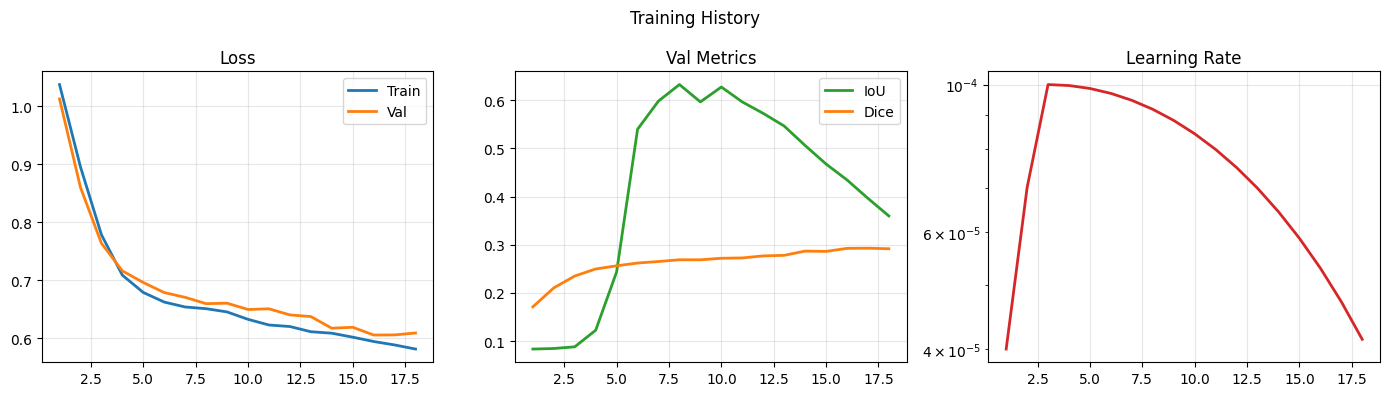

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   linewidth=2)
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["val_iou"],  label="IoU",  linewidth=2, color="tab:green")
axes[1].plot(epochs_ran, history["val_dice"], label="Dice", linewidth=2, color="tab:orange")
axes[1].set_title("Val Metrics"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history["lr"], linewidth=2, color="tab:red")
axes[2].set_title("Learning Rate"); axes[2].set_yscale("log"); axes[2].grid(alpha=0.3)

plt.suptitle("Training History", fontsize=12)
plt.tight_layout()
plt.savefig(str(Path(CFG["output_dir"]) / "training_history.png"), dpi=150)
plt.show()

## 8 · Evaluation & Threshold Sweep

In [19]:
# Load best checkpoint
ckpt = torch.load(str(ckpt_dir / "best.pth"), map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded best checkpoint  (epoch {ckpt['epoch']}, IoU={ckpt['best_iou']:.4f})")

# Collect all predictions on test set
test_ds     = CraterDataset(DATA_ROOT, "test", CFG["image_size"])
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"],
                         shuffle=False, num_workers=0)

all_probs, all_masks = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test inference"):
        opt  = batch["optical"].to(DEVICE)
        dem  = batch["dem"].to(DEVICE)
        preds = model(opt, dem).cpu()
        all_probs.append(preds)
        all_masks.append(batch["mask"])

all_probs = torch.cat(all_probs, dim=0)
all_masks = torch.cat(all_masks, dim=0)
print(f"Collected {len(all_probs)} test predictions")

Loaded best checkpoint  (epoch 8, IoU=0.5985)


Test inference:   0%|          | 0/5 [00:00<?, ?it/s]

Collected 20 test predictions


In [20]:
# Threshold sweep
thresholds  = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
sweep_iou   = []
sweep_dice  = []
sweep_prec  = []
sweep_rec   = []

print(f"{'Thr':>5}  {'IoU':>7}  {'Dice':>7}  {'Prec':>7}  {'Rec':>7}")
print("-" * 40)
for thr in thresholds:
    m = SegmentationMetrics(threshold=thr)
    m.update(all_probs, all_masks)
    r = m.compute()
    sweep_iou.append(r["iou"])
    sweep_dice.append(r["dice_hard"])
    sweep_prec.append(r["precision"])
    sweep_rec.append(r["recall"])
    print(f"{thr:>5.2f}  {r['iou']:>7.4f}  {r['dice_hard']:>7.4f}  "
          f"{r['precision']:>7.4f}  {r['recall']:>7.4f}")

best_idx = int(np.argmax(sweep_iou))
BEST_THR = thresholds[best_idx]
print(f"\nBest threshold: {BEST_THR:.2f}  IoU={sweep_iou[best_idx]:.4f}")

  Thr      IoU     Dice     Prec      Rec
----------------------------------------
 0.25   0.1039   0.1882   0.1039   1.0000
 0.30   0.1039   0.1882   0.1039   1.0000
 0.35   0.1039   0.1882   0.1039   1.0000
 0.40   0.1039   0.1882   0.1039   1.0000
 0.45   0.1074   0.1939   0.1074   1.0000
 0.50   0.6450   0.7842   0.6450   1.0000
 0.55   0.7437   0.8530   0.7439   0.9997
 0.60   0.8203   0.9013   0.8211   0.9988
 0.65   0.8825   0.9376   0.8846   0.9974
 0.70   0.9192   0.9579   0.9237   0.9947

Best threshold: 0.70  IoU=0.9192


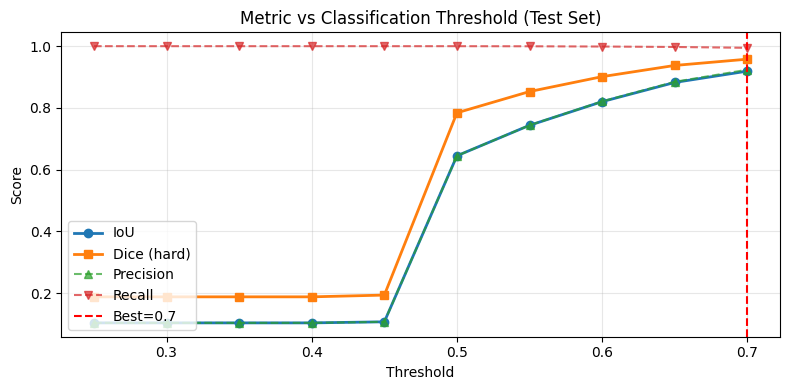

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, sweep_iou,  "o-", label="IoU",       linewidth=2)
ax.plot(thresholds, sweep_dice, "s-", label="Dice (hard)",linewidth=2)
ax.plot(thresholds, sweep_prec, "^--",label="Precision",  linewidth=1.5, alpha=0.7)
ax.plot(thresholds, sweep_rec,  "v--",label="Recall",     linewidth=1.5, alpha=0.7)
ax.axvline(BEST_THR, color="red", linestyle="--", label=f"Best={BEST_THR}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Metric vs Classification Threshold (Test Set)")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9 · Inference & Visualisation

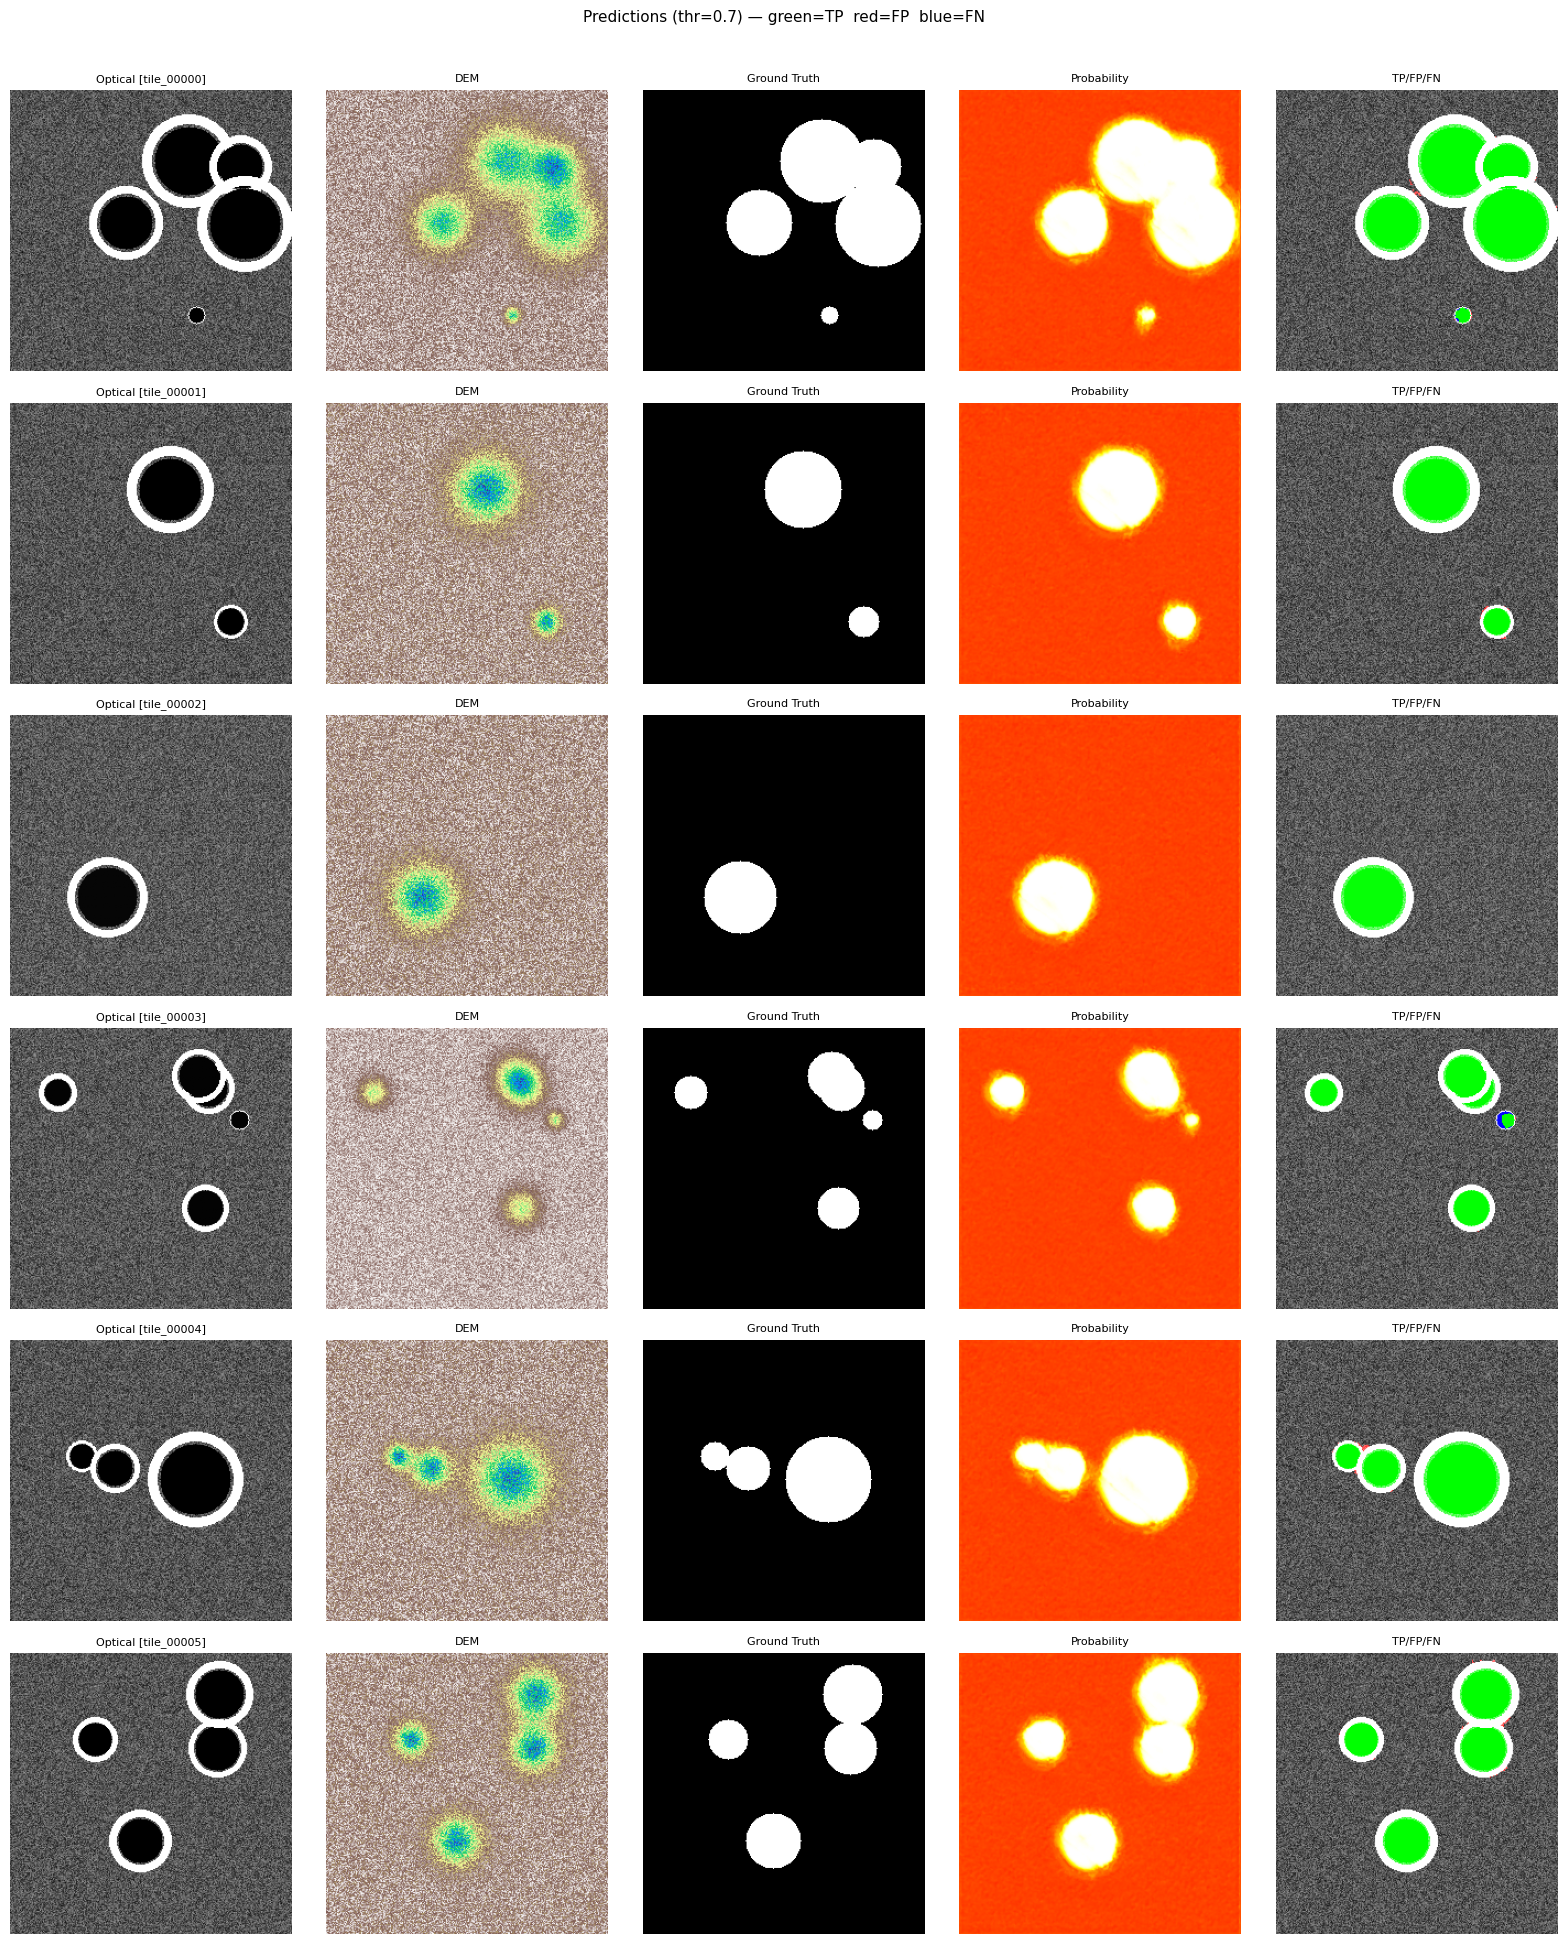

In [22]:
@torch.no_grad()
def predict(model, optical_arr, dem_arr, image_size, device):
    """Run model on a single (H,W) optical/dem pair."""
    def resize_if_needed(a):
        if a.shape[0] != image_size or a.shape[1] != image_size:
            return cv2.resize(a, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
        return a

    opt_r = resize_if_needed(optical_arr)
    dem_r = resize_if_needed(dem_arr)
    opt_t = torch.from_numpy(opt_r).float().unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)
    dem_t = torch.from_numpy(dem_r).float().unsqueeze(0).unsqueeze(0).to(device)
    model.eval()
    prob  = model(opt_t, dem_t).squeeze().cpu().numpy()   # (H,W)
    # Resize back to original if needed
    if optical_arr.shape[:2] != (image_size, image_size):
        prob = cv2.resize(prob, (optical_arr.shape[1], optical_arr.shape[0]),
                          interpolation=cv2.INTER_LINEAR)
    return prob


def show_predictions(model, dataset, n=6, thr=0.5, device=DEVICE, image_size=256):
    fig, axes = plt.subplots(n, 5, figsize=(16, n * 3.2))
    for i in range(n):
        sample = dataset[i]
        opt    = sample["optical"].squeeze().numpy()
        dem    = sample["dem"].squeeze().numpy()
        gt     = sample["mask"].squeeze().numpy()

        prob   = predict(model, opt, dem, image_size, device)
        pred_b = (prob >= thr).astype(np.float32)

        # Overlay: TP=green, FP=red, FN=blue
        rgb = np.stack([opt, opt, opt], axis=-1)
        rgb[..., 1] = np.where((pred_b==1) & (gt==1), 1.0, rgb[..., 1])  # TP green
        rgb[..., 0] = np.where((pred_b==1) & (gt==0), 1.0, rgb[..., 0])  # FP red
        rgb[..., 2] = np.where((pred_b==0) & (gt==1), 1.0, rgb[..., 2])  # FN blue

        for col, (img, title, cmap, vr) in enumerate([
            (opt,    "Optical",     "gray",    None),
            (dem,    "DEM",         "terrain", None),
            (gt,     "Ground Truth","gray",    [0,1]),
            (prob,   "Probability", "hot",     [0,1]),
            (rgb,    "TP/FP/FN",    None,      None),
        ]):
            ax = axes[i, col]
            kw = {"cmap": cmap} if cmap else {}
            if vr: kw["vmin"], kw["vmax"] = vr
            ax.imshow(img, **kw)
            ax.set_title(f"{title}" + (f" [{sample['stem']}]" if col==0 else ""),
                         fontsize=8)
            ax.axis("off")

    plt.suptitle(f"Predictions (thr={thr}) — green=TP  red=FP  blue=FN",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(str(Path(CFG["output_dir"]) / "predictions.png"),
                dpi=130, bbox_inches="tight")
    plt.show()


show_predictions(model, test_ds, n=6, thr=BEST_THR)

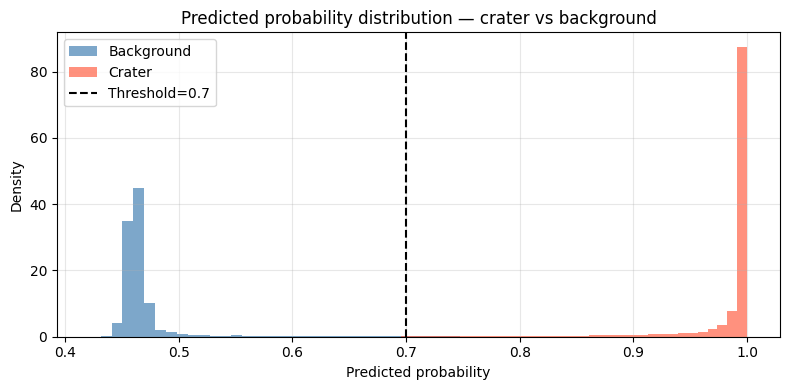

Crater pixels  — mean prob: 0.9823  median: 0.9987
BG pixels      — mean prob: 0.4711  median: 0.4622


In [23]:
# Distribution of predicted probabilities (crater vs background)
crater_probs = all_probs[all_masks >= 0.5].numpy().flatten()
bg_probs     = all_probs[all_masks <  0.5].numpy().flatten()

# Subsample if huge
rng = np.random.default_rng(0)
if len(bg_probs) > 100_000:
    bg_probs = rng.choice(bg_probs, 100_000, replace=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bg_probs,     bins=60, alpha=0.7, color="steelblue", label="Background", density=True)
ax.hist(crater_probs, bins=60, alpha=0.7, color="tomato",    label="Crater",     density=True)
ax.axvline(BEST_THR, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold={BEST_THR}")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Density")
ax.set_title("Predicted probability distribution — crater vs background")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Crater pixels  — mean prob: {crater_probs.mean():.4f}  "
      f"median: {np.median(crater_probs):.4f}")
print(f"BG pixels      — mean prob: {bg_probs.mean():.4f}  "
      f"median: {np.median(bg_probs):.4f}")

## 10 · Export & Next Steps

### Export to TorchScript
```python
scripted = torch.jit.script(model)
scripted.save("craternet_scripted.pt")
```

### Export to ONNX
```python
dummy_opt = torch.randn(1, 1, 256, 256)
dummy_dem = torch.randn(1, 1, 256, 256)
torch.onnx.export(model.cpu(), (dummy_opt, dummy_dem),
                  "craternet.onnx", opset_version=17,
                  input_names=["optical","dem"],
                  output_names=["mask"])
```

### Tips for real data
- **Class imbalance**: craters are typically <5% of pixels.  
  Raise `pos_weight` to `n_background / n_crater` (e.g. 20×).
- **GeoTIFF support**: `pip install rasterio`; pass `.tif` files directly.
- **Higher resolution**: change `image_size=512` — model works at any resolution divisible by 16.
- **Resume training**: pass `resume=True` and load `last.pth` into the model + optimiser.
- **Differential LR**: use a lower LR for the encoder (e.g. 1e-5) vs decoder (1e-4).
- **TensorBoard**:  
  ```bash
  tensorboard --logdir ./runs
  ```

In [24]:
scripted = torch.jit.script(model)
scripted.save("craternet_scripted.pt")

In [27]:
dummy_opt = torch.randn(1, 1, 256, 256)
dummy_dem = torch.randn(1, 1, 256, 256)
torch.onnx.export(model.cpu(), (dummy_opt, dummy_dem),
                  "craternet.onnx", opset_version=17,
                  input_names=["optical","dem"],
                  output_names=["mask"])

W0414 06:38:36.873000 4374 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0414 06:38:40.746000 4374 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0414 06:38:40.752000 4374 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

[torch.onnx] Obtain model graph for `CraterNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CraterNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

Applied 182 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"optical"<FLOAT,[1,1,256,256]>,
                %"dem"<FLOAT,[1,1,256,256]>
            ),
            outputs=(
                %"mask"<FLOAT,[1,1,256,256]>
            ),
            initializers=(
                %"enc_opt.stage1.0.0.weight"<FLOAT,[32,1,3,3]>{Tensor(...)},
                %"enc_opt.stage1.1.conv.0.0.weight"<FLOAT,[32,1,3,3]>{Tensor(...)},
                %"enc_opt.stage1.1.conv.1.weight"<FLOAT,[16,32,1,1]>{Tensor(...)},
                %"enc_opt.stage2.0.conv.1.0.weight"<FLOAT,[96,1,3,3]>{Tensor(...)},
                %"enc_dem.stage1.0.0.weight"<FLOAT,[32,1,3,3]>{Tensor(...)},
                %"enc_dem.stage1.1.conv.0.0.weight"<FLOAT,[32,1,3,3]>

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
